An example to demonstrate window dynamic mode decomposition

We take a 2D time varying system given by dx/dt = A(t)x
where x = [x1,x2]', A(t) = [0,w(t);-w(t),0],
w(t)=1+epsilon\*t, epsilon=0.1. The slowly time varying eigenvlaues of A(t)
are pure imaginary, +(1+0.1t)j and -(1+0.1t)j, where j is the imaginary unit.

At time step k, define two matrix X(k) = [x(k-w+1),x(k-w+2),...,x(k)],
Y(k) = [y(k-w+1),y(k-w+2),...,y(k)], that contain the recent w snapshot pairs
from a finite time window, we would like to compute Ak = Yk\*pinv(Xk). This can
be done by brute-force mini-batch DMD, and by efficient rank-2 updating window
DMD algrithm. For window DMD, at time k+1, we need to forget the old snapshot
pair xold = x(k-w+1), yold = y(k-w+1), and remember the new snapshot pair xnew
= x(k+1), ynew = y(k+1). Mini-batch DMD computes DMD matrix by taking the
pseudo-inverse directly. Window DMD computes the DMD matrix by using efficient
rank-2 update idea.

We compare the performance of window DMD with the brute-force mini-batch DMD
approach in terms of tracking time varying eigenvalues, by comparison with
the analytical solution. They should agree with each other (up to machine
round-offer errors).

Authors:
Hao Zhang
Clarence W. Rowley

References:
Zhang, Hao, Clarence W. Rowley, Eric A. Deem, and Louis N. Cattafesta. "Online dynamic mode decomposition for time-varying systems." SIAM Journal on Applied Dynamical Systems 18, no. 3 (2019): 1586-1609.

Date created: April 2017


In [ ]:
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from river.compose import Pipeline
from river.decomposition.odmd import OnlineDMD
from scipy.integrate import odeint

sys.path.append("..")
from functions.plot import set_size
from functions.rolling import Rolling

In [ ]:
%load_ext autoreload
%autoreload 2

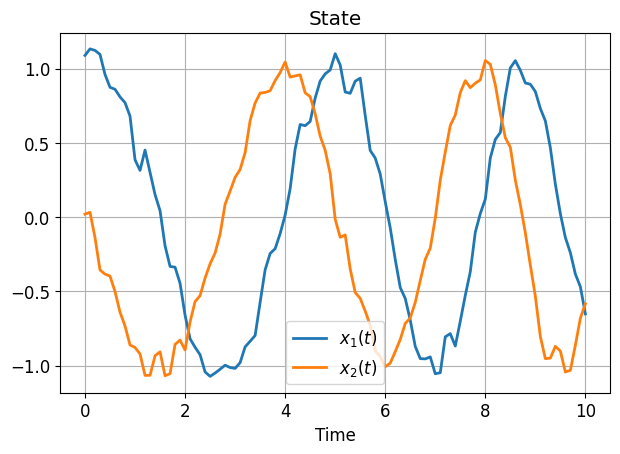

In [ ]:
# [donotremove]
# define dynamics
epsilon = 1e-1


def dyn(x: list[float], t: float) -> list[float]:
    x1, x2 = x
    return [(1 + epsilon * t) * x2, -(1 + epsilon * t) * x1]


# integrate from initial condition [1,0]
dt = 0.1
tspan = np.linspace(0, 10, 101)
t = tspan[1:]

x0 = [1.0, 0.0]
xsol = odeint(dyn, x0, tspan)
x, y = xsol[:-1, :], xsol[1:, :]
# add noise
np.random.seed(0)
n, m = x.shape
noise = np.random.normal(0, 0.05, size=x.shape)
x += noise
y += noise

# true dynamics, true eigenvalues
gt_eigvals = np.empty((n, m), dtype=complex)
for k in range(n):
    A = np.array([[0, (1 + epsilon * t[k])], [-(1 + epsilon * t[k]), 0]])
    gt_eigvals[k] = np.linalg.eigvals(A)

# visualize snapshots
fig, axs = plt.subplots(figsize=set_size("article", fraction=1))

axs.plot(tspan, xsol[:, 0], linewidth=2.0, label="$x_1(t)$")
axs.plot(tspan, xsol[:, 1], linewidth=2.0, label="$x_2(t)$")
axs.set_title("State")
axs.set_xlabel("Time")
axs.legend()
axs.grid(True)

In [ ]:
from collections import deque


# Row-wise SSE
def sse(x: np.ndarray, y: np.ndarray) -> np.floating:
    return np.linalg.norm(x - y)


class MiniBatchDMD:
    def __init__(self, w: int) -> None:
        self.w = w
        self.X: deque = deque(maxlen=w)
        self.Y: deque = deque(maxlen=w)
        self.A: np.ndarray

    def learn_one(self, x: np.ndarray, y: np.ndarray | None = None) -> None:
        if y is None:
            if not hasattr(self, "_x_first"):
                self._x_first = x
                return
            y = x
            x = self._x_first
            self._x_first = y
        self.X.append(x)
        self.Y.append(y)
        self.A = np.array(self.Y).T.dot(np.linalg.pinv(np.array(self.X).T))

    def learn_many(self, X: np.ndarray, Y: np.ndarray) -> None:
        for x, y in zip(X, Y, strict=False):
            self.learn_one(x, y)

In [ ]:
w = 20
models = {
    "Mini-batch DMD": MiniBatchDMD(w),
    "Online DMD, wf=1.0": OnlineDMD(w=1.0, exponential_weighting=True),
    "Online DMD, wf=0.95": OnlineDMD(w=0.95, exponential_weighting=True),
    "Window DMD, w=10, wf=1.0": Rolling(
        OnlineDMD(w=1.0, exponential_weighting=True),
        window_size=w,
    ),
    "Window DMD, w=10, wf=0.95": Rolling(
        OnlineDMD(w=0.95, exponential_weighting=True),
        window_size=w,
    ),
    # TODO: Find out why this does not work as expected
    # "Hanked DMD, w=10, wf=0.95": Hankelizer(2)
    # | OnlineDMD(w=0.95, exponential_weighting=True),
    # "Hanked Window DMD, w=10, wf=0.95": Hankelizer(2)
    # | Rolling(OnlineDMD(w=0.95, exponential_weighting=True), window_size=w),
}

eigvals: dict[str, np.ndarray] = {}
sses: dict[str, tuple[np.floating, np.floating]] = {}
exectimes: dict[str, float] = {}
for name, model in models.items():
    model_ = model._last_step if isinstance(model, Pipeline) else model
    eigvals[name] = np.empty((n, m), dtype=complex)
    start = time.time()
    for k, (x_, y_) in enumerate(zip(x, y, strict=False)):
        model.learn_one(x_)
        if k > 1:
            eigvals[name][k, :] = (
                np.log(np.linalg.eigvals(model_.A[-m:, -m:])) / dt
            )
    end = time.time()
    sses[name] = (
        sse(gt_eigvals[w:, 0].real, eigvals[name][w:, 0].real),
        sse(gt_eigvals[w:, 0].imag, eigvals[name][w:, 0].imag),
    )
    exectimes[name] = end - start
    print(f"{name}, time = {exectimes[name]:.2f}s")

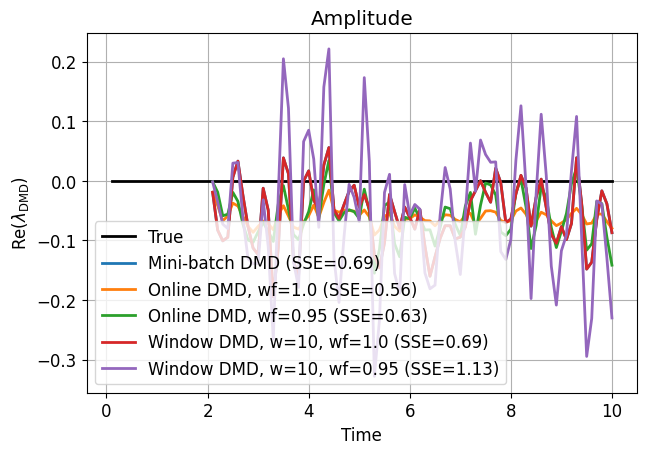

In [ ]:
# [donotremove]
fig, axs = plt.subplots(figsize=set_size("article", fraction=1))

plt.plot(t, gt_eigvals[:, 0].real, "k-", label="True", linewidth=2.0)

for name, result in eigvals.items():
    axs.plot(
        t[w:],
        result[w:, 0].real,
        label=f"{name} (SSE={sses[name][0]:.2f})",
        linewidth=2.0,
    )

# Set title and font properties
axs.set_title("Amplitude")
axs.set_xlabel("Time")
axs.set_ylabel("Re($\\lambda_{\\mathrm{DMD}}$)")
axs.legend()
axs.grid(True)

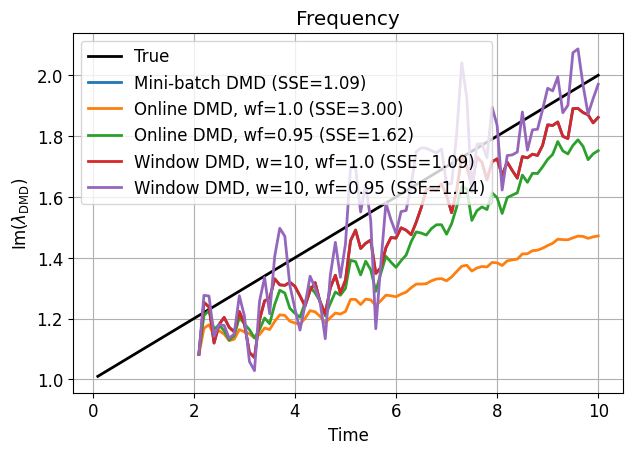

In [ ]:
# [donotremove]
fig, axs = plt.subplots(figsize=set_size("article", fraction=1))

plt.plot(t, gt_eigvals[:, 0].imag, "k-", label="True", linewidth=2.0)

for name, result in eigvals.items():
    axs.plot(
        t[w:],
        result[w:, 0].imag,
        label=f"{name} (SSE={sses[name][1]:.2f})",
        linewidth=2.0,
    )

# Set title and font properties
axs.set_title("Frequency")
axs.set_xlabel("Time")
axs.set_ylabel("Im($\\lambda_{\\mathrm{DMD}}$)")
axs.legend()
axs.grid(True)